In [13]:
#!pip install transformers

In [14]:
#!pip install pandas

In [15]:
#!pip install scikit-learn

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [17]:
import pandas as pd
import numpy as np
import torch

In [18]:
## Loading the data and preprocessing

In [19]:
import torch
import torch.nn as nn
from transformers import AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

In [20]:
class CrisisDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        # self.text = dataframe.text
        # self.labels = dataframe.humanitarian_label
        self.max_len = max_len

    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        encoding = self.tokenizer(
            row['text'],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            #add_special_tokens=True,
            return_tensors="pt",
            #return_token_type_ids=False,
            #return_attention_mask=True,
            
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'crisis_type': int(row["humanitarian_label"]),
            'informativeness': int(row["informativeness_label"]),
        }

In [21]:
class CrisisClassifier(nn.Module):
    def __init__(self, n_classes):
        super(CrisisClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained("bert-base-uncased")
        
        self.info_classifier = nn.Sequential(
                nn.Linear(768, 256),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(256, 2))

        # Gating mechanism
        self.gate = nn.Sequential(
            nn.Linear(768, 768),
            nn.Sigmoid()
        )
        
        # Second task: crisis classifier
        self.crisis_classifier = nn.Sequential(
                nn.Linear(768, 256),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(256, n_classes))


    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        
        informativeness_logits = self.info_classifier(pooled_output)
        informativeness_probs = torch.softmax(informativeness_logits, dim=1)
        informativeness_score = informativeness_probs[:, 1].unsqueeze(1)
        
        gated_output = informativeness_score * pooled_output
        #print("I am here")

        crisis_logits = self.crisis_classifier(gated_output)
        #print(crisis_logits)
    
        return informativeness_logits, crisis_logits

In [22]:
#criterion_informativeness = nn.CrossEntropyLoss()
#criterion_crisis = nn.CrossEntropyLoss()

In [23]:
def train(model, dataloader, optimizer, criterion_informativeness, criterion_crisis, device, alpha=0.5):
    model.train()
    total_loss = 0
    
    for idx, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        crisis_labels = batch['crisis_type'].to(device)
        informativeness_labels = batch['informativeness'].to(device)

        optimizer.zero_grad()

        informativeness_logits, crisis_logits = model(input_ids, attention_mask)
        #print("I am here2")

        loss1 = criterion_informativeness(informativeness_logits, informativeness_labels)

        # Create a mask
        informative_mask = informativeness_labels == 1  # shape: [B]

        # Apply mask to crisis loss
        #print(crisis_logits[informative_mask])
        #print(crisis_labels[informative_mask])
        if informative_mask.sum() > 0:
            loss2 = criterion_crisis(
                crisis_logits[informative_mask],
                crisis_labels[informative_mask]
            )
        else:
            loss2 = torch.tensor(0.0, device=device)
        
        #loss2 = criterion_crisis(crisis_logits, crisis_labels)
        #print(f"loss1: {loss1}, loss2: {loss2}")
        loss = alpha*loss1 + (1-alpha)*loss2

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # _, preds = torch.max(crisis_logits, dim=1)
        # correct_predictions += torch.sum(preds == crisis_labels)
        if idx % 10 == 0:  # Log every 10 minibatches
            print(f"Batch {idx}/{len(dataloader)} | Loss: {loss.item():.4f} | Informativeness Loss: {loss1.item():.4f} | Crisis Loss: {loss2.item():.4f}")


    return total_loss / len(dataloader) #, correct_predictions.double() / len(dataloader.dataset)

In [24]:
# def eval(model, dataloader, device):
#     model.eval()
#     all_informativeness_preds = []
#     all_informativeness_labels = []
#     all_crisis_preds = []
#     all_crisis_labels = []

#     with torch.no_grad():
#         for batch in dataloader:
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)

#             informativeness_logits, crisis_logits = model(input_ids, attention_mask)
#             informativeness_preds = torch.argmax(informativeness_logits, dim=1).cpu().numpy()
#             crisis_preds = torch.argmax(crisis_logits, dim=1).cpu().numpy()
            

#             all_informativeness_preds.extend(informativeness_preds)
#             all_informativeness_labels.extend(batch['informativeness'])
#             all_crisis_preds.extend(crisis_preds)
#             all_crisis_labels.extend(batch['crisis_type'])
    
#     informativeness_accuracy = accuracy_score(all_informativeness_labels, all_informativeness_preds)
#     crisis_accuracy = accuracy_score(all_crisis_labels, all_crisis_preds)
    
#     return informativeness_accuracy, crisis_accuracy

In [25]:
from sklearn.metrics import accuracy_score
import numpy as np

def eval(model, dataloader, device):
    model.eval()
    
    all_info_preds = []
    all_info_labels = []
    all_crisis_preds = []
    all_crisis_labels = []

    total_info_loss = 0
    total_crisis_loss = 0
    n_info = 0
    n_crisis = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            info_true = batch["informativeness"].to(device)
            crisis_true = batch["crisis_type"].to(device)

            informativeness_logits, crisis_logits = model(input_ids, attention_mask)


            info_loss = criterion_informativeness(informativeness_logits, info_true)
            total_info_loss += info_loss.item() * input_ids.size(0)
            n_info += input_ids.size(0)
            
            info_preds = torch.argmax(informativeness_logits, dim=1).cpu().numpy()
            crisis_preds = torch.argmax(crisis_logits, dim=1).cpu().numpy()

            all_info_preds.extend(info_preds)
            all_info_labels.extend(batch["informativeness"].numpy())
            all_crisis_preds.extend(crisis_preds)
            all_crisis_labels.extend(batch["crisis_type"].numpy())

            mask = info_true == 1
            if mask.sum() > 0:
                loss_crisis = criterion_crisis(crisis_logits[mask], crisis_true[mask])
                total_crisis_loss += loss_crisis.item() * mask.sum().item()
                n_crisis += mask.sum().item()


    # Accuracy
    #print(np.array(all_crisis_labels)[np.array(all_info_labels) == 1])
    info_acc = accuracy_score(all_info_labels, all_info_preds)
    crisis_acc = accuracy_score(
        np.array(all_crisis_labels)[np.array(all_info_preds) == 1],
        np.array(all_crisis_preds)[np.array(all_info_preds) == 1]
    ) if n_crisis > 0 else float('nan')

    # Loss
    avg_info_loss = total_info_loss / n_info
    avg_crisis_loss = total_crisis_loss / n_crisis if n_crisis > 0 else 0.0

    return avg_info_loss, avg_crisis_loss, info_acc, crisis_acc

In [26]:
if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    device = torch.device("mps")

MPS not available because the current PyTorch install was not built with MPS enabled.


In [27]:
device = torch.device("cuda:2")

In [28]:
import pandas as pd

# Load the pre-split CSVs
train_df = pd.read_csv("combined_train.tsv", sep="\t")
val_df = pd.read_csv("combined_dev.tsv", sep="\t")

# Drop any rows with missing values in the important columns
train_df = train_df.dropna(subset=["text", "informativeness_label", "humanitarian_label"]).reset_index(drop=True)
val_df = val_df.dropna(subset=["text", "informativeness_label", "humanitarian_label"]).reset_index(drop=True)


In [29]:
train_df.groupby("humanitarian_label").size()

humanitarian_label
affected_individual                     2454
caution_and_advice                      2101
displaced_and_evacuations                359
donation_and_volunteering               5181
infrastructure_and_utilities_damage     3540
injured_or_dead_people                  1940
missing_and_found_people                 373
not_humanitarian                       36090
requests_or_needs                       4827
response_efforts                         780
sympathy_and_support                    3549
dtype: int64

In [30]:
# Informativeness labels
#info_labels = sorted(train_df["informativeness_label"].unique())
info_labels = ['not_informative', 'informative']
info2id = {label: idx for idx, label in enumerate(info_labels)}
id2info = {idx: label for label, idx in info2id.items()}

# Humanitarian (crisis type) labels
hum_labels = sorted(train_df["humanitarian_label"].unique())
hum2id = {label: idx for idx, label in enumerate(hum_labels)}
id2hum = {idx: label for label, idx in hum2id.items()}

In [31]:
info_labels

['not_informative', 'informative']

In [32]:
train_df["informativeness_label"] = train_df["informativeness_label"].map(info2id)
val_df["informativeness_label"] = val_df["informativeness_label"].map(info2id)

train_df["humanitarian_label"] = train_df["humanitarian_label"].map(hum2id)
val_df["humanitarian_label"] = val_df["humanitarian_label"].map(hum2id)

In [33]:
train_df.groupby('humanitarian_label').size()

humanitarian_label
0      2454
1      2101
2       359
3      5181
4      3540
5      1940
6       373
7     36090
8      4827
9       780
10     3549
dtype: int64

In [34]:
train_df.groupby('informativeness_label').size()

informativeness_label
0    36090
1    25104
dtype: int64

In [35]:
data_train = CrisisDataset(train_df, tokenizer, max_len=128)
data_val = CrisisDataset(val_df, tokenizer, max_len=128)

In [36]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
model = CrisisClassifier(n_classes=11).to(device)

train_loader = DataLoader(data_train, batch_size=32, shuffle=True)
val_loader = DataLoader(data_val, batch_size=32, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion_informativeness = nn.CrossEntropyLoss()
criterion_crisis = nn.CrossEntropyLoss()

for epoch in range(10):
    print(f"Epoch {epoch + 1}/{3}")
    train_loss = train(model, train_loader, optimizer, criterion_informativeness, criterion_crisis, device, alpha=0.1)
    print(f"Train Loss: {train_loss:.4f}")

    avg_info_loss, avg_crisis_loss, informativeness_accuracy, crisis_accuracy = eval(model, val_loader, device)
    torch.save(model.state_dict(), f"teacher_model_bert_version2_opt_human_epoch_{epoch}.pt")
    print(f"Informativeness Accuracy: {informativeness_accuracy:.4f}")
    print(f"Crisis Accuracy: {crisis_accuracy:.4f}")

Epoch 1/3
Batch 0/1913 | Loss: 2.2659 | Informativeness Loss: 0.7190 | Crisis Loss: 2.4378
Batch 10/1913 | Loss: 2.1628 | Informativeness Loss: 0.6773 | Crisis Loss: 2.3279
Batch 20/1913 | Loss: 2.1834 | Informativeness Loss: 0.6881 | Crisis Loss: 2.3495
Batch 30/1913 | Loss: 2.0694 | Informativeness Loss: 0.6917 | Crisis Loss: 2.2224
Batch 40/1913 | Loss: 1.9488 | Informativeness Loss: 0.7761 | Crisis Loss: 2.0791
Batch 50/1913 | Loss: 1.8015 | Informativeness Loss: 0.9294 | Crisis Loss: 1.8983
Batch 60/1913 | Loss: 1.7148 | Informativeness Loss: 1.1457 | Crisis Loss: 1.7780
Batch 70/1913 | Loss: 1.8840 | Informativeness Loss: 1.1539 | Crisis Loss: 1.9651
Batch 80/1913 | Loss: 1.6662 | Informativeness Loss: 0.6837 | Crisis Loss: 1.7754
Batch 90/1913 | Loss: 1.7338 | Informativeness Loss: 0.7407 | Crisis Loss: 1.8441
Batch 100/1913 | Loss: 1.4151 | Informativeness Loss: 0.6910 | Crisis Loss: 1.4955
Batch 110/1913 | Loss: 1.6873 | Informativeness Loss: 0.5648 | Crisis Loss: 1.8120
Batch

In [ ]:
## Earlier Output

Epoch 1/3
Train Loss: 1.2296
Informativeness Accuracy: 0.8916
Crisis Accuracy: 0.8189
Epoch 2/3
Train Loss: 0.6880
Informativeness Accuracy: 0.9059
Crisis Accuracy: 0.8412
Epoch 3/3
Train Loss: 0.4871
Informativeness Accuracy: 0.9134
Crisis Accuracy: 0.8474

In [28]:
avg_info_loss, avg_crisis_loss, informativeness_accuracy, crisis_accuracy = eval(model, val_loader, device)

In [41]:
# # Save model weights
# torch.save(model.state_dict(), "gated_bert_model.pt")

# # Save label mappings
# import json
# with open("label_mappings.json", "w") as f:
#     json.dump({
#         "info2id": info2id,
#         "id2info": id2info,
#         "hum2id": hum2id,
#         "id2hum": id2hum
#     }, f, indent=4)

In [42]:
## test-data

test_df = pd.read_csv("combined_test.tsv", sep="\t")
test_df = test_df.dropna(subset=["text", "informativeness_label", "humanitarian_label"]).reset_index(drop=True)

# Apply the same label mappings
test_df["informativeness_label"] = test_df["informativeness_label"].map(info2id)
test_df["humanitarian_label"] = test_df["humanitarian_label"].map(hum2id)

data_test = CrisisDataset(test_df, tokenizer, max_len=128)
test_loader = DataLoader(data_test, batch_size=32)

# Evaluation
info_preds, info_true, crisis_preds, crisis_true = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        info_logits, crisis_logits = model(input_ids, attention_mask)

        info_preds.extend(torch.argmax(info_logits, dim=1).cpu().tolist())
        crisis_preds.extend(torch.argmax(crisis_logits, dim=1).cpu().tolist())

        info_true.extend(batch["informativeness"].tolist())
        crisis_true.extend(batch["crisis_type"].tolist())


In [43]:
from sklearn.metrics import accuracy_score

info_accuracy = accuracy_score(info_true, info_preds)
print(f"Informativeness Accuracy: {info_accuracy:.4f}")

Informativeness Accuracy: 0.9200


In [32]:
import numpy as np

info_true = np.array(info_true)
crisis_true = np.array(crisis_true)
crisis_preds = np.array(crisis_preds)

# Filter where informativeness == 1
mask = info_true == 1

filtered_crisis_true = crisis_true[mask]
filtered_crisis_preds = crisis_preds[mask]

if len(filtered_crisis_true) > 0:
    crisis_accuracy = accuracy_score(filtered_crisis_true, filtered_crisis_preds)
    print(f"Crisis Type Accuracy (Informative Only): {crisis_accuracy:.4f}")
else:
    print("No informative tweets found in test set for crisis accuracy.")

Crisis Type Accuracy (Informative Only): 0.8447


In [32]:
#!pip install seaborn

Informativeness Report:

                 precision    recall  f1-score   support

not_informative       0.95      0.91      0.93     10244
    informative       0.87      0.93      0.90      7101

       accuracy                           0.92     17345
      macro avg       0.91      0.92      0.92     17345
   weighted avg       0.92      0.92      0.92     17345

Crisis Type Report:

                                     precision    recall  f1-score   support

                affected_individual       0.77      0.83      0.80       693
                 caution_and_advice       0.45      0.80      0.58       583
          displaced_and_evacuations       0.57      0.56      0.56        99
          donation_and_volunteering       0.15      0.87      0.26      1453
infrastructure_and_utilities_damage       0.55      0.80      0.65      1003
             injured_or_dead_people       0.82      0.87      0.84       560
           missing_and_found_people       0.53      0.41      0.46   

/opt/anaconda3/envs/cs7643-a3-nlp/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/cs7643-a3-nlp/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/cs7643-a3-nlp/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

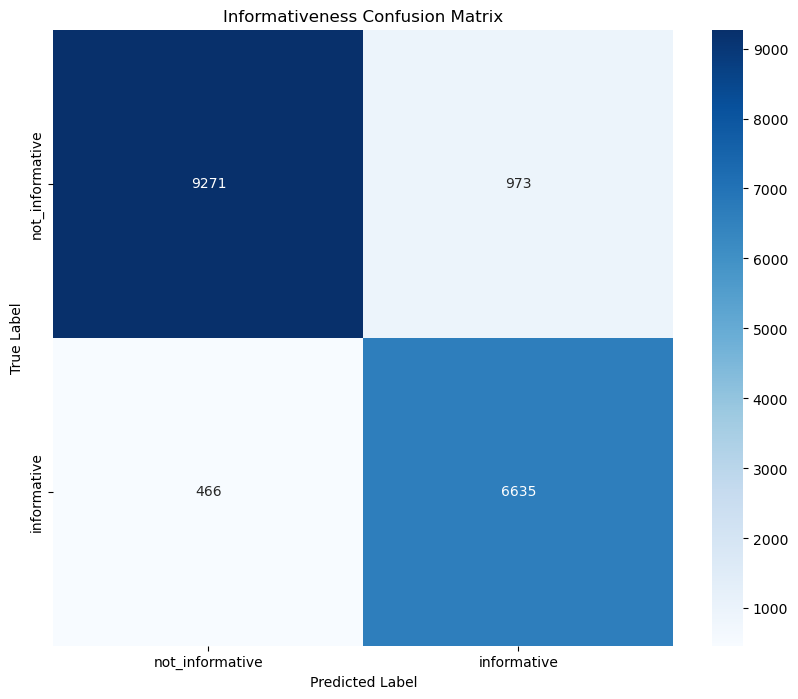

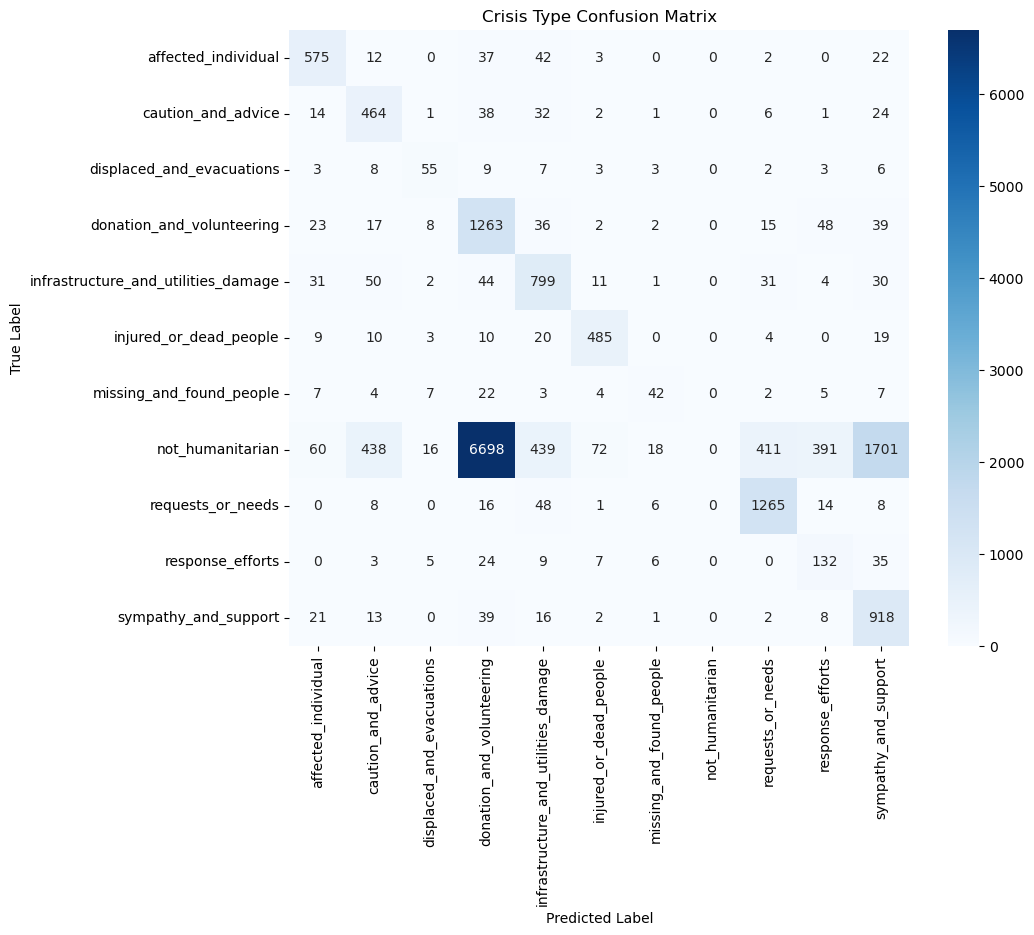

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Info report
print("Informativeness Report:\n")
print(classification_report(info_true, info_preds, target_names=[id2info[i] for i in sorted(id2info)]))

# Crisis report
print("Crisis Type Report:\n")
print(classification_report(crisis_true, crisis_preds, target_names=[id2hum[i] for i in sorted(id2hum)]))

# Confusion matrix
def plot_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

plot_cm(info_true, info_preds, [id2info[i] for i in sorted(id2info)], "Informativeness Confusion Matrix")
plot_cm(crisis_true, crisis_preds, [id2hum[i] for i in sorted(id2hum)], "Crisis Type Confusion Matrix")


In [ ]:
###### distillation 

In [64]:
import sys
import os

# Add folder to path
module_path = '/Users/moukthikayerramilli/Documents/Deep_learning_7643/group_project/knowledge_distillation_crisis_nlp'
if module_path not in sys.path:
    sys.path.append(module_path)

%load_ext autoreload
%autoreload 2

from CrisisClassifierTransformer import CrisisClassifierTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, temperature=2.0, alpha=0.5):
    student_soft = F.log_softmax(student_logits / temperature, dim=1)
    teacher_soft = F.softmax(teacher_logits / temperature, dim=1)
    distill_loss = F.kl_div(student_soft, teacher_soft, reduction='batchmean') * (temperature ** 2)
    return distill_loss

In [92]:
def train_student_with_distillation_one_epoch(student_model, teacher_model, dataloader, optimizer, device, alpha=1.0, beta=1.0):
    student_model.train()
    teacher_model.eval()
    
    losses, informative_losses, humanitarian_losses = [], [], []
    progress_bar = tqdm(dataloader, ascii=True)
    for batch_idx, data in enumerate(progress_bar):
        #print(data)
        input_ids = data['input_ids'].to(device)
        attention_mask = data['attention_mask'].to(device)
        # attention_mask = data['attention_mask'].to(device)
        label_informative = data['informativeness'].to(device)
        label_humanitarian = data['crisis_type'].to(device)

        logits_informative, logits_humanitarian = student_model(input_ids)
        loss_informative = nn.CrossEntropyLoss()(logits_informative, label_informative)
    
        mask = label_informative == 1  # 1 == informative
        if mask.any():
            loss_humanitarian = nn.CrossEntropyLoss()(logits_humanitarian[mask], label_humanitarian[mask])
        else:
            loss_humanitarian = torch.tensor(0., dtype=torch.float, device=device)

        # Teacher prediction
        with torch.no_grad():
            teacher_informativeness_logits, teacher_crisis_logits = teacher_model(input_ids=input_ids, attention_mask=attention_mask)

        loss_distillation = distillation_loss(logits_humanitarian, teacher_crisis_logits)
            
        # scale only humanitarian loss because it's the more complex task
        loss = loss_informative + alpha * loss_humanitarian + beta * loss_distillation

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # total_loss += loss.item()
        # total_informative_loss += loss_informative.item()
        # total_humanitarian_loss += loss_humanitarian.item()
        
        losses.append(loss.item())
        informative_losses.append(loss_informative.item())
        humanitarian_losses.append(loss_humanitarian.item())

        progress_bar.set_description_str(
            f"Batch {batch_idx + 1} | Total: {loss.item():.4f} | Info: {loss_informative.item():.4f} | Human: {loss_humanitarian.item():.4f}"
        )
        
        # if batch_idx == 100:
        #     break
    
    return {
        'mean_losses': np.mean(losses),
        'mean_informative_losses': np.mean(informative_losses),
        'mean_humanitarian_losses': np.mean(humanitarian_losses),
    }

In [93]:
def eval_student(model, dataloader, device):
    model.eval()
    
    all_info_preds = []
    all_info_labels = []
    all_crisis_preds = []
    all_crisis_labels = []

    total_info_loss = 0
    total_crisis_loss = 0
    n_info = 0
    n_crisis = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            info_true = batch["informativeness"].to(device)
            crisis_true = batch["crisis_type"].to(device)

            informativeness_logits, crisis_logits = model(input_ids)


            info_loss = criterion_informativeness(informativeness_logits, info_true)
            total_info_loss += info_loss.item() * input_ids.size(0)
            n_info += input_ids.size(0)
            
            info_preds = torch.argmax(informativeness_logits, dim=1).cpu().numpy()
            crisis_preds = torch.argmax(crisis_logits, dim=1).cpu().numpy()

            all_info_preds.extend(info_preds)
            all_info_labels.extend(batch["informativeness"].numpy())
            all_crisis_preds.extend(crisis_preds)
            all_crisis_labels.extend(batch["crisis_type"].numpy())

            mask = info_true == 1
            if mask.sum() > 0:
                loss_crisis = criterion_crisis(crisis_logits[mask], crisis_true[mask])
                total_crisis_loss += loss_crisis.item() * mask.sum().item()
                n_crisis += mask.sum().item()


    # Accuracy
    #print(np.array(all_crisis_labels)[np.array(all_info_labels) == 1])
    info_acc = accuracy_score(all_info_labels, all_info_preds)
    crisis_acc = accuracy_score(
        np.array(all_crisis_labels)[np.array(all_info_labels) == 1],
        np.array(all_crisis_preds)[np.array(all_info_labels) == 1]
    ) if n_crisis > 0 else float('nan')

    # Loss
    avg_info_loss = total_info_loss / n_info
    avg_crisis_loss = total_crisis_loss / n_crisis if n_crisis > 0 else 0.0

    return avg_info_loss, avg_crisis_loss, info_acc, crisis_acc

In [94]:
from tqdm import tqdm

## Initialize student model
student_model = CrisisClassifierTransformer(input_size=tokenizer.vocab_size, output_size=11).to(device)
## Loading teacher model
teacher_model = CrisisClassifier(n_classes=11).to(device)
teacher_model.load_state_dict(torch.load("gated_bert_model.pt"))

## Init parameters
train_losses, informative_losses, humanitarian_losses = [], [], []
validation_informative_losses, validation_humanitarian_losses = [], []
device = torch.device("mps")
alpha = 1.0
beta = 1.0
optimizer = torch.optim.AdamW(student_model.parameters(), lr=2e-5)

## Train models
for epoch in range(10):
    training_output = train_student_with_distillation_one_epoch(student_model, teacher_model, train_loader, optimizer, device, alpha=alpha, beta=beta)
    avg_info_loss, avg_crisis_loss, informativeness_accuracy, crisis_accuracy = eval_student(student_model, val_loader, device)
    print(f"Test Informativeness Accuracy: {informativeness_accuracy:.4f}")
    print(f"Test Crisis Accuracy: {crisis_accuracy:.4f}")
    
    print(
        f"Epoch {epoch}: Train Tot={training_output['mean_losses']:.4f}, "
        f"Inf={training_output['mean_informative_losses']:.4f}, "
        f"Hum={training_output['mean_humanitarian_losses']:.4f} | "
    )
    train_losses.append(training_output['mean_losses'])
    informative_losses.append(training_output['mean_informative_losses'])
    humanitarian_losses.append(training_output['mean_humanitarian_losses'])
    validation_informative_losses.append(avg_info_loss)
    validation_humanitarian_losses.append(avg_crisis_loss)

/var/folders/lv/dl7v7b757935j6n7vdz8tc6c0000gn/T/ipykernel_41729/2509036329.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher_model.load_state_dict(torch.load("gat

Test Informativeness Accuracy: 0.7245
Test Crisis Accuracy: 0.4472
Epoch 0: Train Tot=4.4464, Inf=0.5850, Hum=1.8162 | 


Batch 1913 | Total: 4.5448 | Info: 0.6095 | Human: 1.5833: 100%|##########################################| 1913/1913 [04:27<00:00,  7.14it/s]


Test Informativeness Accuracy: 0.7928
Test Crisis Accuracy: 0.5088
Epoch 1: Train Tot=3.7324, Inf=0.4826, Hum=1.5461 | 


Batch 1913 | Total: 4.9180 | Info: 0.9348 | Human: 2.3455: 100%|##########################################| 1913/1913 [04:33<00:00,  6.99it/s]


...

Test Informativeness Accuracy: 0.8488
Test Crisis Accuracy: 0.6660
Epoch 7: Train Tot=2.3678, Inf=0.3459, Hum=1.0184 | 


Batch 1913 | Total: 0.3200 | Info: 0.1172 | Human: 0.0192: 100%|##########################################| 1913/1913 [04:27<00:00,  7.16it/s]


Test Informativeness Accuracy: 0.8558
Test Crisis Accuracy: 0.6818
Epoch 8: Train Tot=2.2552, Inf=0.3357, Hum=0.9720 | 


Batch 1913 | Total: 1.4975 | Info: 0.2893 | Human: 0.5082: 100%|##########################################| 1913/1913 [04:26<00:00,  7.17it/s]


Test Informativeness Accuracy: 0.8573
Test Crisis Accuracy: 0.6826
Epoch 9: Train Tot=2.1526, Inf=0.3251, Hum=0.9292 | 


In [95]:
## Train models
for epoch in range(10):
    training_output = train_student_with_distillation_one_epoch(student_model, teacher_model, train_loader, optimizer, device, alpha=alpha, beta=beta)
    avg_info_loss, avg_crisis_loss, informativeness_accuracy, crisis_accuracy = eval_student(student_model, val_loader, device)
    print(f"Test Informativeness Accuracy: {informativeness_accuracy:.4f}")
    print(f"Test Crisis Accuracy: {crisis_accuracy:.4f}")
    
    print(
        f"Epoch {epoch}: Train Tot={training_output['mean_losses']:.4f}, "
        f"Inf={training_output['mean_informative_losses']:.4f}, "
        f"Hum={training_output['mean_humanitarian_losses']:.4f} | "
    )
    train_losses.append(training_output['mean_losses'])
    informative_losses.append(training_output['mean_informative_losses'])
    humanitarian_losses.append(training_output['mean_humanitarian_losses'])
    validation_informative_losses.append(avg_info_loss)
    validation_humanitarian_losses.append(avg_crisis_loss)

Batch 1913 | Total: 0.3649 | Info: 0.1798 | Human: 0.0349: 100%|##########################################| 1913/1913 [04:10<00:00,  7.64it/s]


Test Informativeness Accuracy: 0.8575
Test Crisis Accuracy: 0.6983
Epoch 0: Train Tot=2.0711, Inf=0.3180, Hum=0.8958 | 


Batch 1913 | Total: 2.4773 | Info: 0.2243 | Human: 1.1710: 100%|##########################################| 1913/1913 [04:12<00:00,  7.59it/s]


Test Informativeness Accuracy: 0.8599
Test Crisis Accuracy: 0.7024
Epoch 1: Train Tot=1.9911, Inf=0.3112, Hum=0.8614 | 


Batch 1913 | Total: 0.7359 | Info: 0.1183 | Human: 0.2279: 100%|##########################################| 1913/1913 [04:13<00:00,  7.54it/s]


...

Test Informativeness Accuracy: 0.8719
Test Crisis Accuracy: 0.7206
Epoch 7: Train Tot=1.6126, Inf=0.2727, Hum=0.6955 | 


Batch 1913 | Total: 3.4368 | Info: 0.1722 | Human: 1.8435: 100%|########################################| 1913/1913 [1:58:48<00:00,  3.73s/it]


Test Informativeness Accuracy: 0.8711
Test Crisis Accuracy: 0.7228
Epoch 8: Train Tot=1.5544, Inf=0.2672, Hum=0.6687 | 


Batch 1913 | Total: 2.5428 | Info: 0.3026 | Human: 0.6554: 100%|##########################################| 1913/1913 [07:47<00:00,  4.09it/s]


Test Informativeness Accuracy: 0.8738
Test Crisis Accuracy: 0.7217
Epoch 9: Train Tot=1.5037, Inf=0.2604, Hum=0.6469 | 


In [96]:
avg_info_loss, avg_crisis_loss, informativeness_accuracy, crisis_accuracy = eval_student(student_model, val_loader, device)
print(f"Informativeness Accuracy: {informativeness_accuracy:.4f}")
print(f"Crisis Accuracy: {crisis_accuracy:.4f}")

Informativeness Accuracy: 0.8738
Crisis Accuracy: 0.7217


In [ ]:
##### old

In [18]:

# Load model
model = CrisisClassifier(n_classes=len(hum2id))
model.load_state_dict(torch.load("gated_bert_model.pt"))
model.to(device)
model.eval()

# Load mappings
with open("label_mappings.json") as f:
    mappings = json.load(f)
    id2info = {int(k): v for k, v in mappings["id2info"].items()}
    id2hum = {int(k): v for k, v in mappings["id2hum"].items()}


/var/folders/lv/dl7v7b757935j6n7vdz8tc6c0000gn/T/ipykernel_39050/991871311.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("gated_bert_m

FileNotFoundError: [Errno 2] No such file or directory: 'gated_bert_model.pt'

In [16]:
train_df = pd.read_csv("combined_train.tsv", sep="\t")
val_df = pd.read_csv("combined_dev.tsv", sep="\t")

In [17]:
train_df.columns

Index(['id', 'text', 'humanitarian_event', 'humanitarian_source',
       'humanitarian_lang', 'humanitarian_lang_conf', 'informativeness_event',
       'informativeness_source', 'informativeness_lang',
       'informativeness_lang_conf', 'informativeness_label',
       'humanitarian_label'],
      dtype='object')

In [20]:
train_df.groupby(['informativeness_label', 'humanitarian_label']).size()

informativeness_label  humanitarian_label                 
informative            affected_individual                     2454
                       caution_and_advice                      2101
                       displaced_and_evacuations                359
                       donation_and_volunteering               5181
                       infrastructure_and_utilities_damage     3540
                       injured_or_dead_people                  1940
                       missing_and_found_people                 373
                       requests_or_needs                       4827
                       response_efforts                         780
                       sympathy_and_support                    3549
not_informative        not_humanitarian                       36090
dtype: int64

In [21]:
val_df.groupby(['informativeness_label', 'humanitarian_label']).size()

informativeness_label  humanitarian_label                 
informative            affected_individual                     367
                       caution_and_advice                      309
                       displaced_and_evacuations                53
                       donation_and_volunteering               763
                       infrastructure_and_utilities_damage     509
                       injured_or_dead_people                  269
                       missing_and_found_people                 55
                       requests_or_needs                       705
                       response_efforts                        113
                       sympathy_and_support                    540
not_informative        not_humanitarian                       5265
dtype: int64

In [ ]:
data_train = pd.read_csv("combined_train.tsv", sep="\t")
data_train = df.dropna(subset=["text", "informativeness_label", "humanitarian_label"])

info2id = {"not_informative": 0, "informative": 1}
data_train["informativeness_label"] = data_train["informativeness_label"].map(info2id)

filtered_for_not_humanitarian = data_train[(data_train["informativeness_label"] == 1) & (data_train["humanitarian_label"] != "not_humanitarian")]

unique_crisis_labels = sorted(filtered_for_not_humanitarian["humanitarian_label"].unique())
hum2id = {label: idx for idx, label in enumerate(unique_crisis_labels)}
id2hum = {v: k for k, v in hum2id.items()}

data_train["humanitarian_label_encoded"] = data_train.apply(
    lambda row: hum2id[row["humanitarian_label"]]
    if row["informativeness_label"] == 1 and row["humanitarian_label"] in hum2id
    else -1,
    axis=1
)